# Import, Split, Clean Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

path = "clean_numeric_data - manually_cleaned_training_data_202601.csv"
df = pd.read_csv(path)

ids = np.loadtxt("trainval_ids.txt", dtype=[("id", "i4")], encoding="utf-16")
trainval_df = df[df["unique_id"].isin(ids["id"])]

# TODO READ IN CORRECCT TRAINING IDS

features = ["unique_id", "Painting", "emotional_intensity", "evokes_sombre", "evokes_content","evokes_calm", "evokes_unease", "prominent_colour_count","prominent_subject_count", "bedroom","office","living_room","dining_room","friends","family","coworkers","by yourself","fall","winter","spring","summer", "clean_monetary_value"]
numeric = ["emotional_intensity", "evokes_sombre", "evokes_content","evokes_calm", "evokes_unease", "prominent_colour_count","prominent_subject_count",  "clean_monetary_value" ]
bool_feats = ["bedroom","office","living_room","dining_room","friends","family","coworkers","by yourself","fall","winter","spring","summer"]
data = trainval_df[features]




In [4]:
#plotting = ["Painting", "emotional_intensity", "evokes_sombre", "evokes_content","evokes_calm", "evokes_unease", "prominent_colour_count","prominent_subject_count",  "Unnamed: 28"]

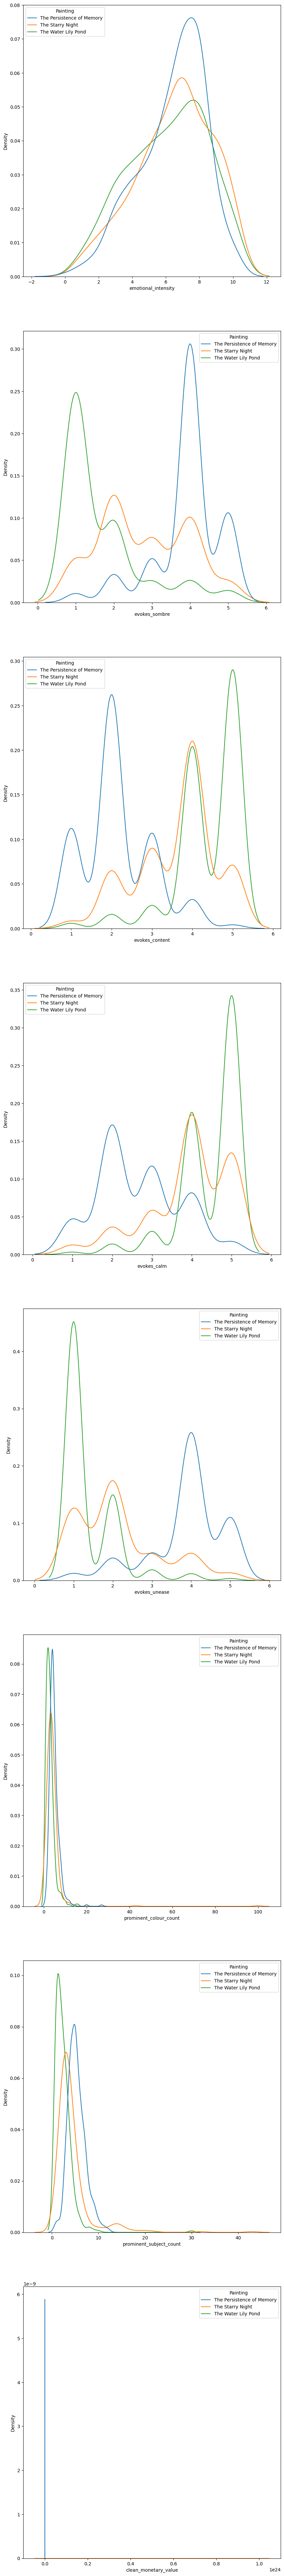

In [5]:

fig, ax = plt.subplots(len(numeric), 1, figsize=(10, 100))

for i in range(len(numeric)):
  sns.kdeplot(data, x=numeric[i], hue="Painting", ax=ax[i])
plt.savefig("numericKDES.png")

/tmp/ipython-input-721357047.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
/tmp/ipython-input-721357047.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
/tmp/ipython-input-721357047.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
/tmp/ipython-input-721357047.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
/tmp/ipython-input-721357047.py:5: UserWarning: 

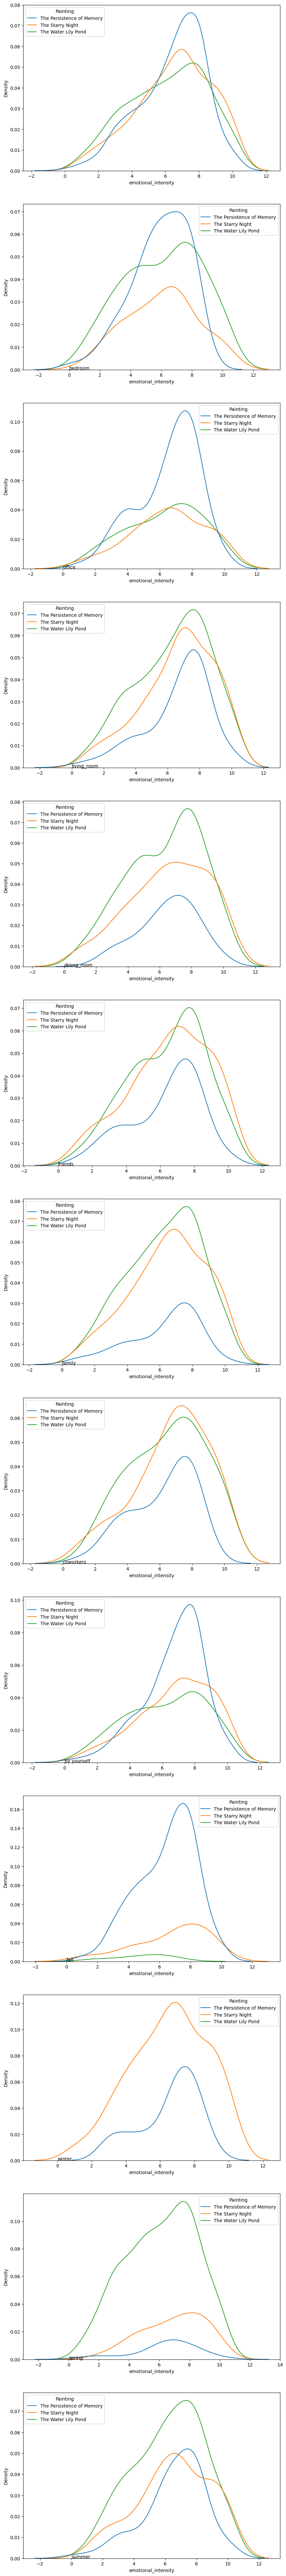

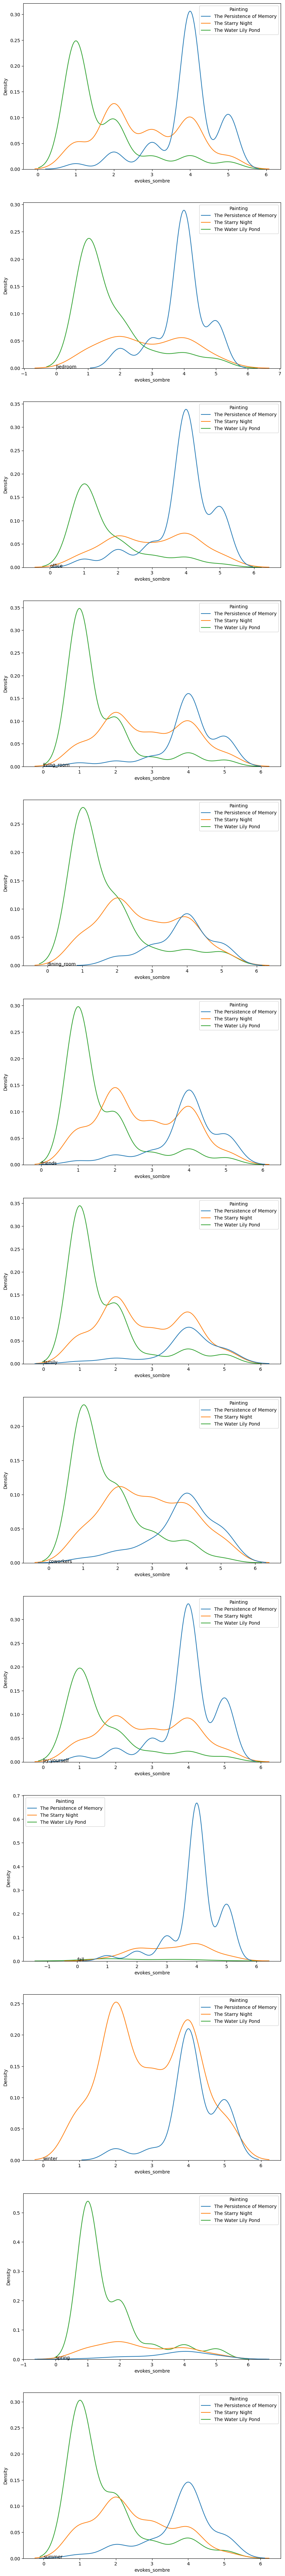

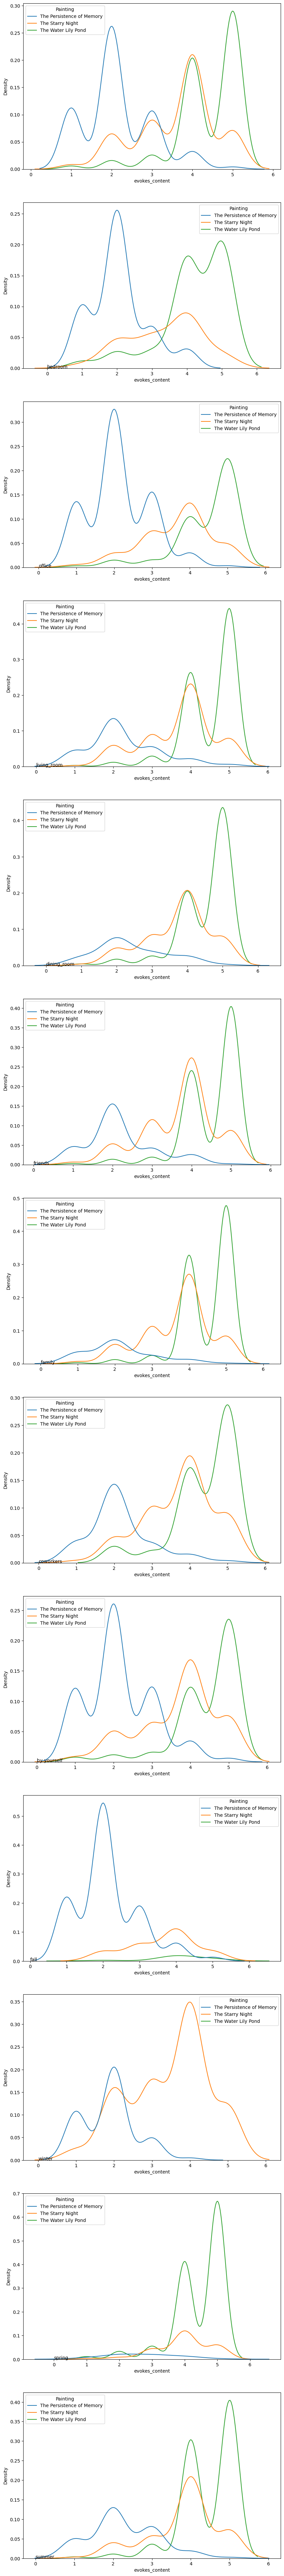

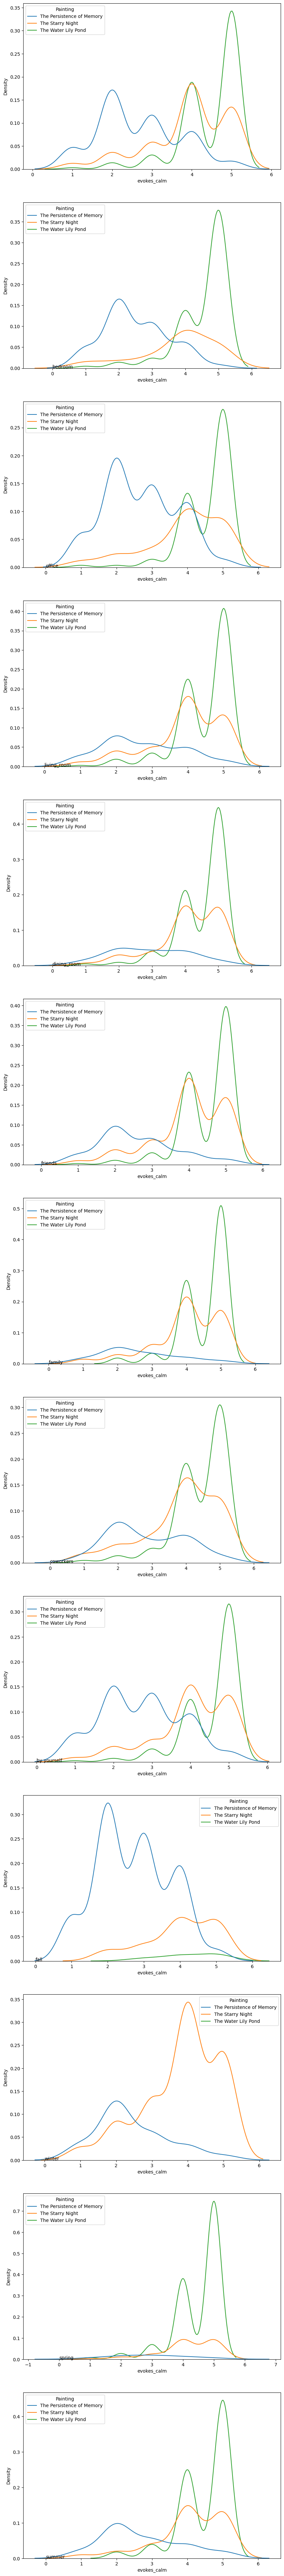

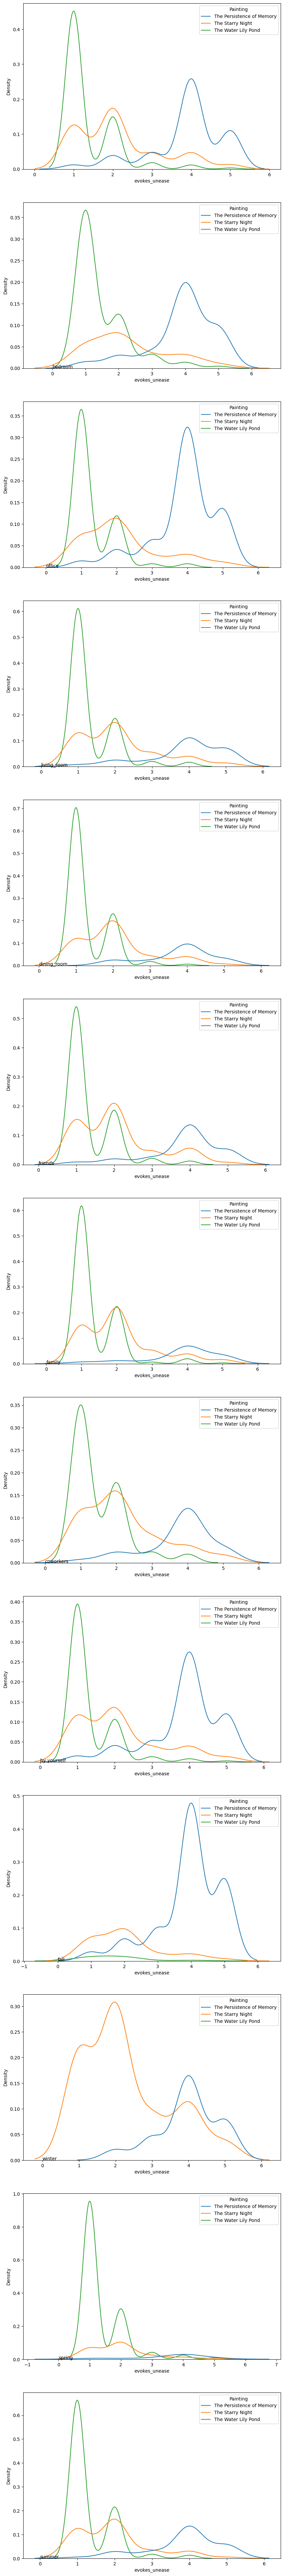

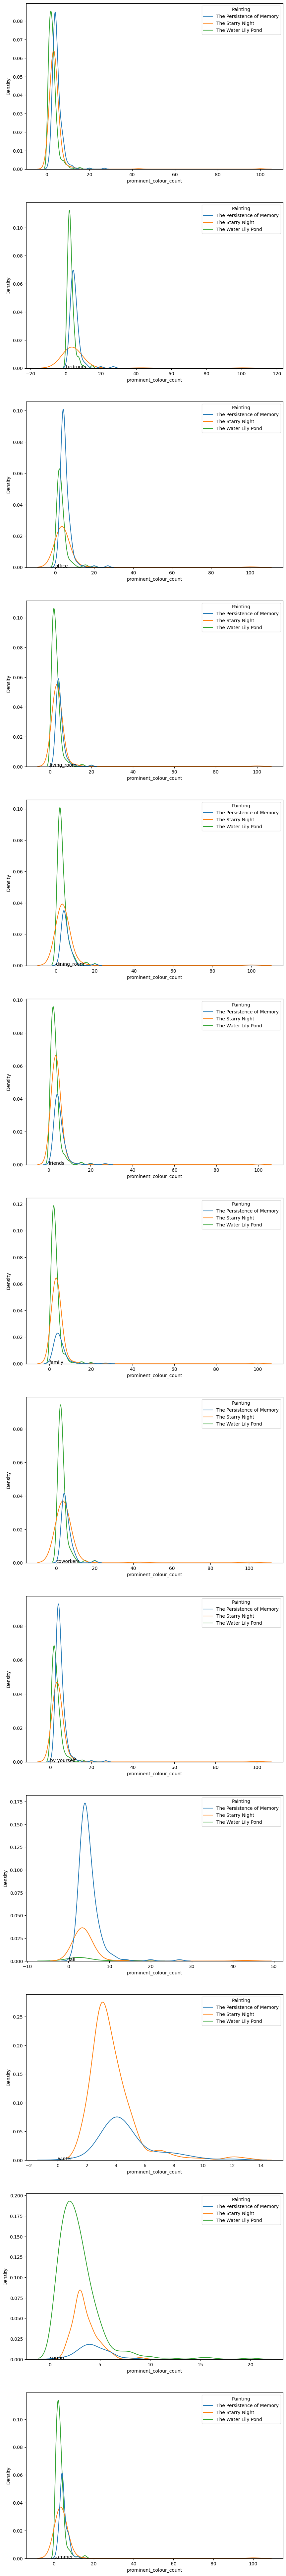

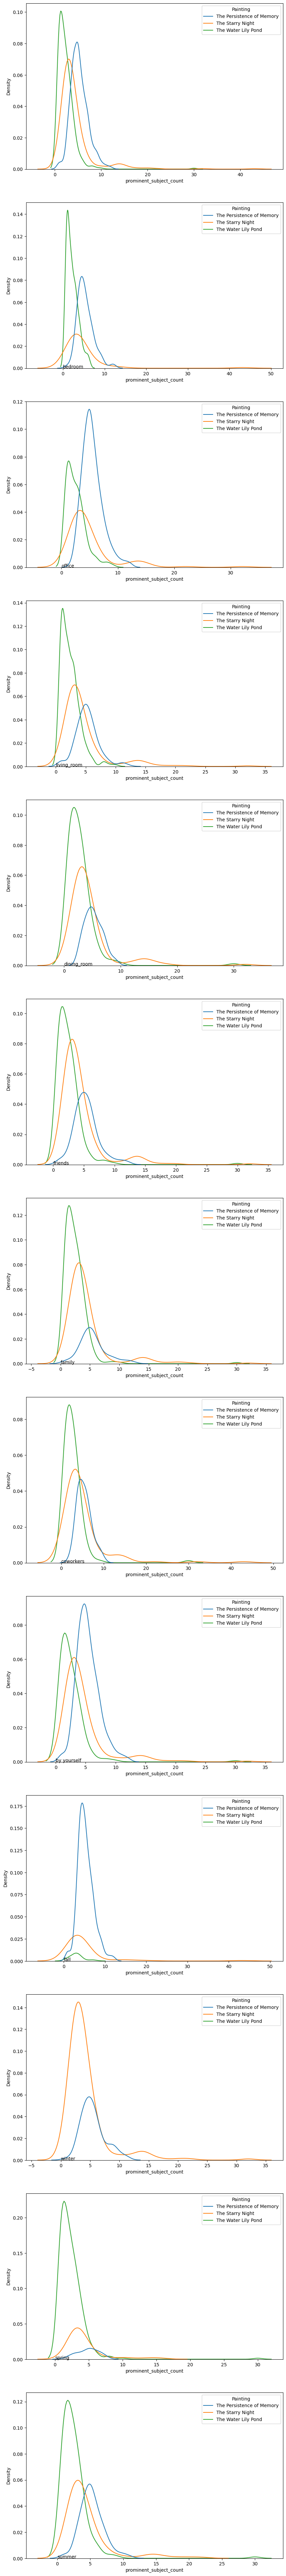

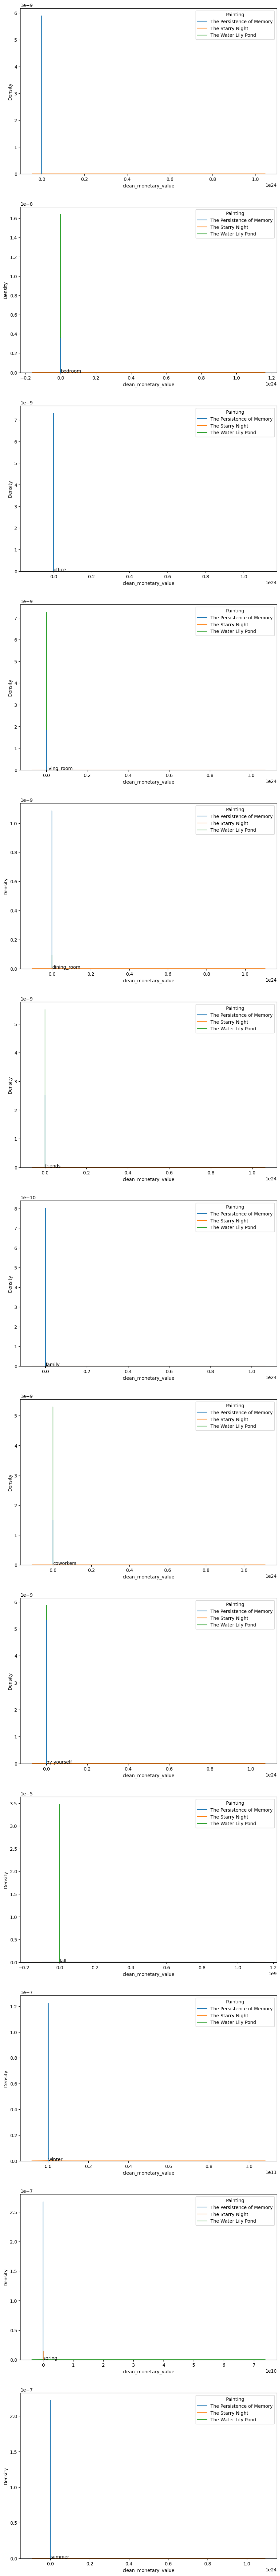

In [6]:
for i in range(len(numeric)):
  fig, ax = plt.subplots(len(bool_feats)+1, 1, figsize=(10, 100))
  sns.kdeplot(data, x=numeric[i], hue="Painting", ax=ax[0])
  for j in range(len(bool_feats)):
      g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
      ax[j+1].text(0, 0, bool_feats[j])
  plt.savefig(f"conditionalKDEs{numeric[i]}.png")

In [7]:
#(df["column_name"] == "A").sum()
for cat in bool_feats:
  #print(df[cat].value_counts())
  print(data.groupby(cat)["Painting"].count())

bedroom
False    893
True     286
Name: Painting, dtype: int64
office
False    750
True     429
Name: Painting, dtype: int64
living_room
False    566
True     613
Name: Painting, dtype: int64
dining_room
False    841
True     338
Name: Painting, dtype: int64
friends
False    541
True     638
Name: Painting, dtype: int64
family
False    590
True     589
Name: Painting, dtype: int64
coworkers
False    885
True     294
Name: Painting, dtype: int64
by yourself
False    491
True     688
Name: Painting, dtype: int64
fall
False    864
True     315
Name: Painting, dtype: int64
winter
False    896
True     283
Name: Painting, dtype: int64
spring
False    744
True     435
Name: Painting, dtype: int64
summer
False    717
True     462
Name: Painting, dtype: int64


# PCA


In [17]:
X = np.array(data.dropna()[numeric])

#Center and Normalize to do correlation PCA. need to stdize bc units are crazy different
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_cen = (X - X_mean) / X_std

In [18]:
pca = PCA()
pca.fit(X_cen)
print(pca.explained_variance_)
eigval = pca.explained_variance_
loadings = pca.components_

[3.12906563 1.76310619 1.10028656 0.80977962 0.51364212 0.27621454
 0.24234279 0.17264847]


In [19]:
#Parallel Analysis of Values
ALPHA = 0.05/len(numeric) #bonferroni coefficient for 0.05 FWER
rng = np.random.default_rng(311)
X_cen_shuffled = X_cen.copy()

eigenvalues = np.ndarray(shape=(len(numeric),1000))
for b in range(1000):
  X_cen_shuffled = rng.permuted(X_cen, axis=1, out=X_cen_shuffled)
  pca = PCA()
  pca.fit(X_cen_shuffled)
  eigenvalues[:,b] = pca.explained_variance_

In [20]:
print("95% quantiles")
print(np.quantile(eigenvalues, 1-ALPHA, axis=1))
print("eigenvalues from dataset")
print(eigval)
print("explained variance")
print(np.cumsum(eigval)/len(numeric))
#the first 4 loadings reached significance

95% quantiles
[2.62056632 1.12280665 0.94790183 0.87282042 0.83149024 0.78887008
 0.75499919 0.71703672]
eigenvalues from dataset
[3.12906563 1.76310619 1.10028656 0.80977962 0.51364212 0.27621454
 0.24234279 0.17264847]
explained variance
[0.3911332  0.61152148 0.7490573  0.85027975 0.91448501 0.94901183
 0.97930468 1.00088574]


In [21]:
loadings

array([[ 0.02271084,  0.43481202, -0.47997758, -0.45982878,  0.50421434,
         0.19014184,  0.2722081 ,  0.06417529],
       [-0.00149396, -0.08400705,  0.13446702,  0.14112603, -0.10775982,
         0.67262244,  0.17993672,  0.67715013],
       [ 0.87281084,  0.10736432,  0.22347153,  0.14158403,  0.03163228,
         0.01143822,  0.36019322, -0.16067979],
       [-0.40456058, -0.15645936,  0.02716545,  0.13717942, -0.10992049,
         0.01934383,  0.82663925, -0.31065399],
       [-0.18939416,  0.80591022,  0.08448113,  0.54676105, -0.0738899 ,
        -0.00903174, -0.05094991, -0.02041291],
       [-0.15996936,  0.25176695,  0.78377105, -0.53807868,  0.03392243,
        -0.05121474,  0.05001894,  0.0303628 ],
       [-0.11203248, -0.23170604,  0.28180499,  0.35813153,  0.8259516 ,
         0.12764623, -0.10798037, -0.12625142],
       [-0.00153113,  0.0361818 ,  0.00380538, -0.1142025 , -0.17962769,
         0.70137153, -0.2523814 , -0.63067213]])

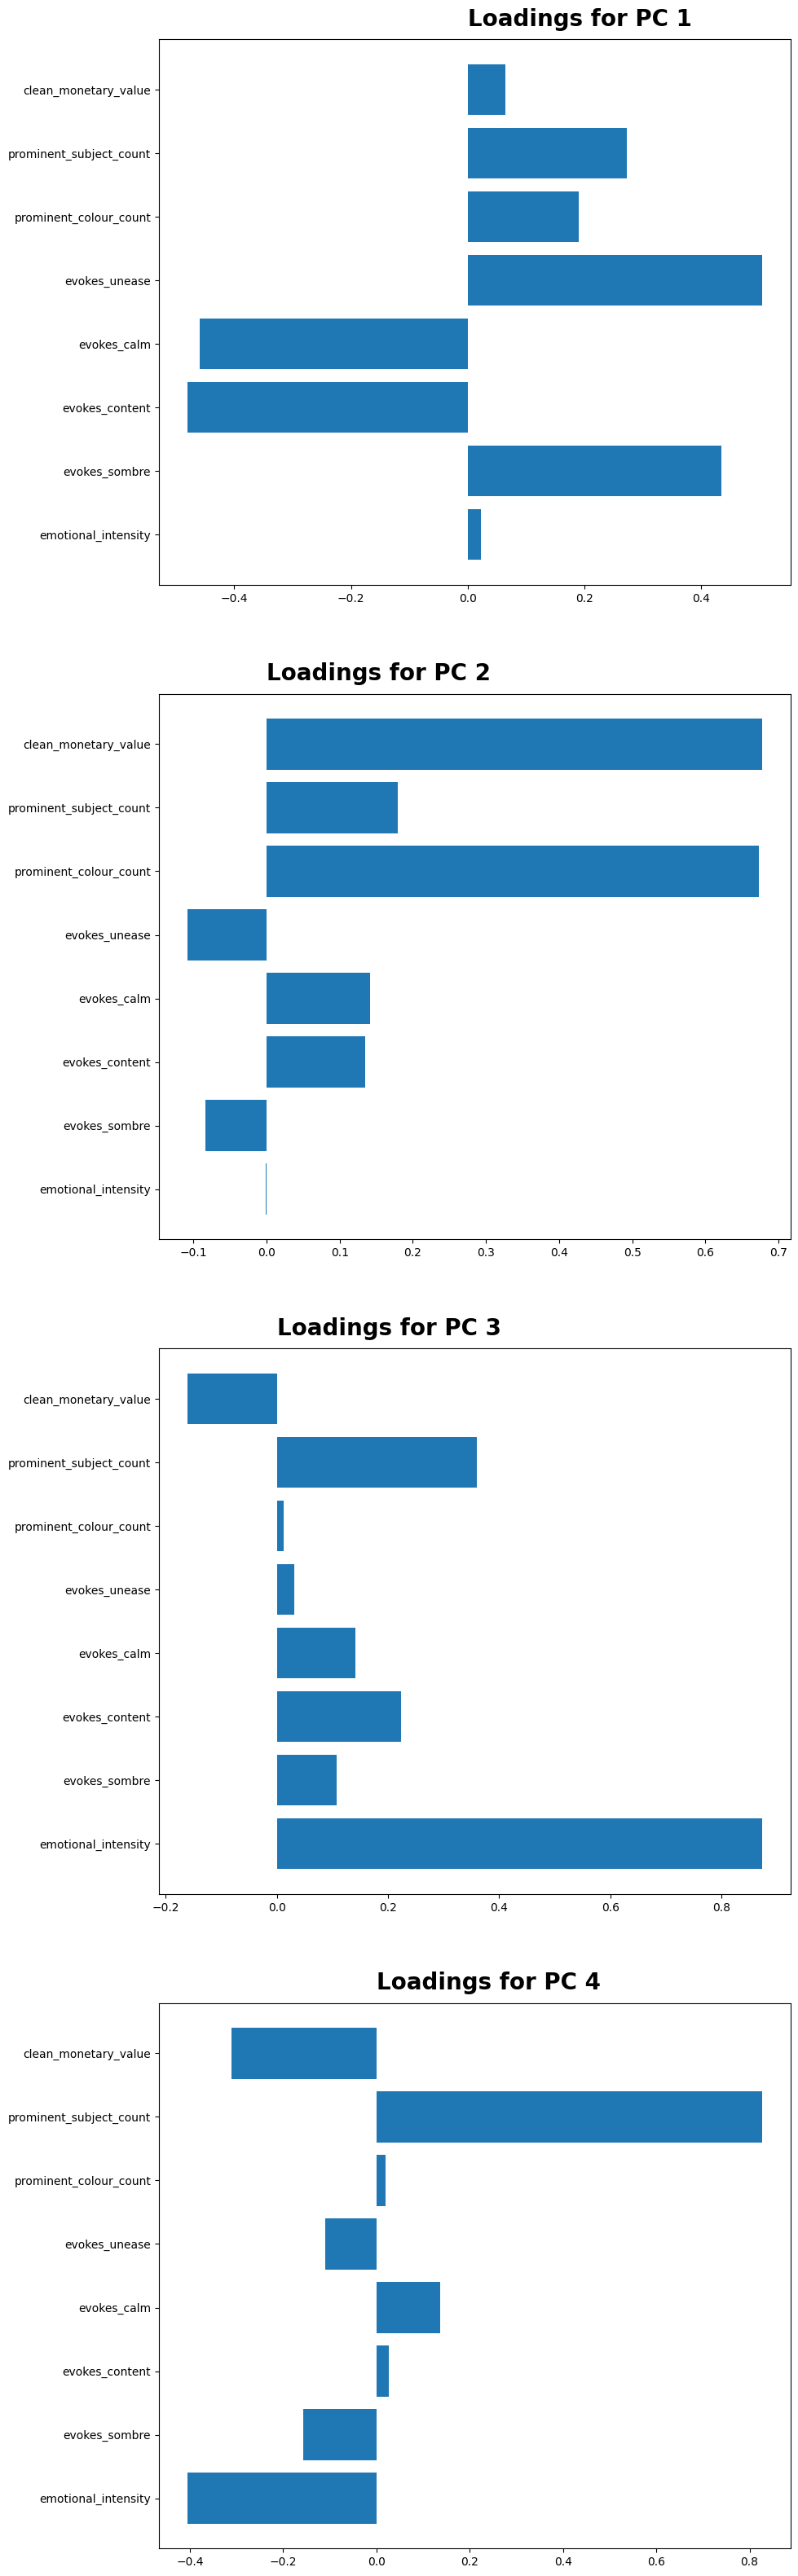

In [22]:
fig, ax = plt.subplots(4, 1, figsize=(10, 40))

for i in range(4):
  ax[i].text(0,8, "Loadings for PC {}".format(i+1), fontsize=20, fontweight="bold")
  ax[i].barh(numeric, loadings[i])
plt.savefig("PCA.png")

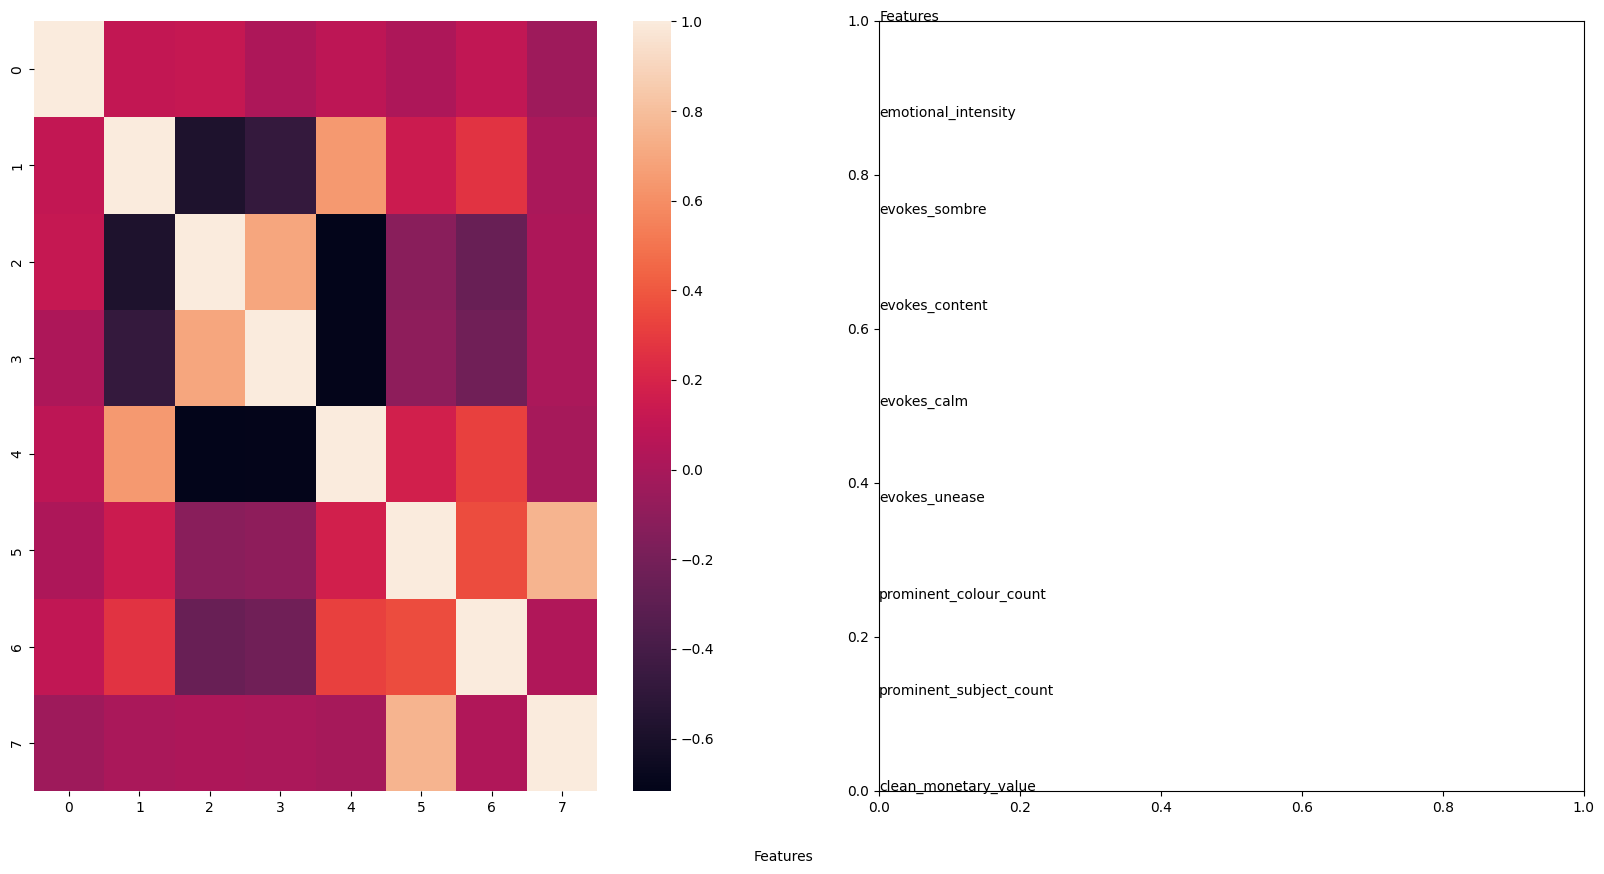

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
S = np.cov(X_cen.T)
g = sns.heatmap(S, ax=ax[0])
g.figure.text(0.5, 0.04, 'Features', ha='center')
ax[1].text(0, 1, "Features")
for i in range(len(numeric)):
  ax[1].text(0, 1 - (i+1)/len(numeric), numeric[i])
fig.savefig("corr_mat.png")

/tmp/ipython-input-2337413336.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])


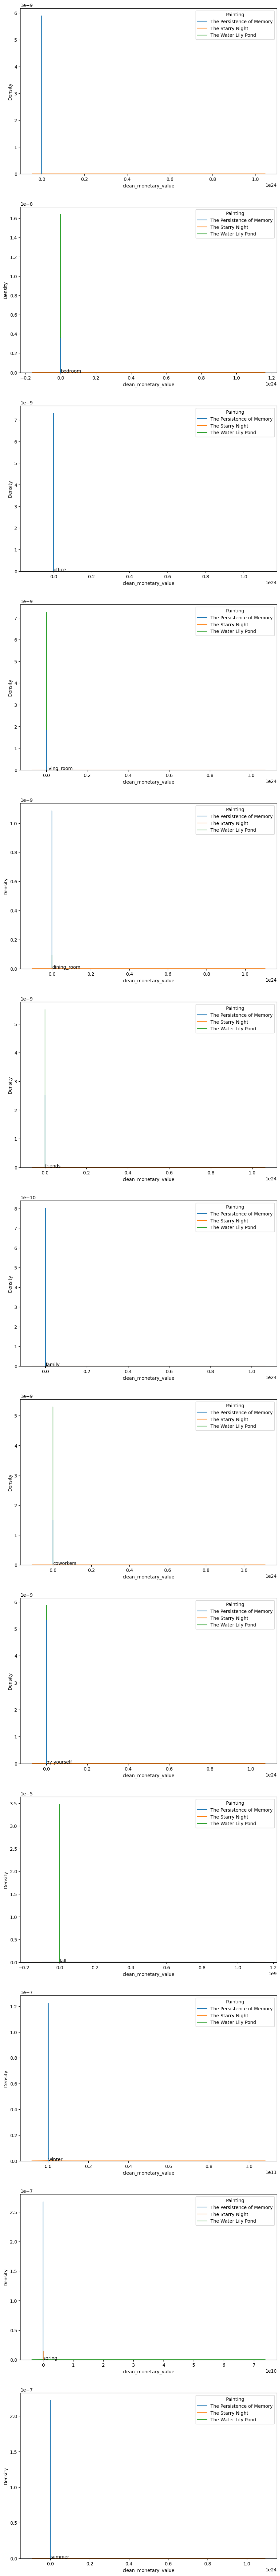

In [24]:
fig, ax = plt.subplots(len(bool_feats)+1, 1, figsize=(10, 100))
sns.kdeplot(data, x=numeric[i], hue="Painting", ax=ax[0])
for j in range(len(bool_feats)):
    g = sns.kdeplot(data[data[bool_feats[j]]], x=numeric[i], hue="Painting", ax=ax[j+1])
    ax[j+1].text(0, 0, bool_feats[j])
plt.savefig(f"conditionalKDEs{numeric[i]}.png")

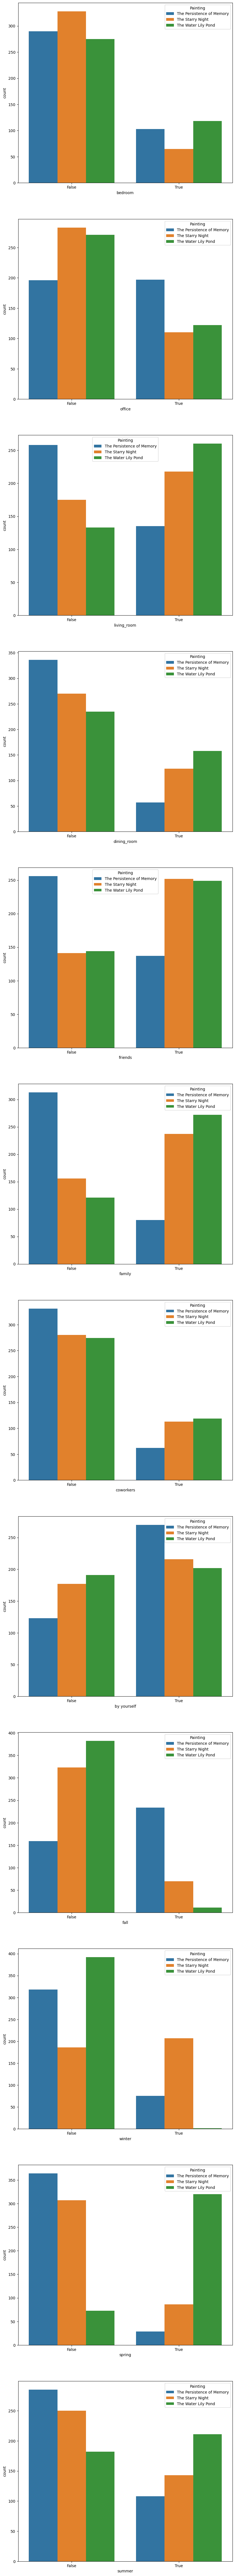

In [25]:
fig, ax = plt.subplots(len(bool_feats), 1, figsize=(10, 10*len(bool_feats)))
for j in range(len(bool_feats)):
  sns.countplot(data, x=bool_feats[j], hue="Painting", ax=ax[j])


# Transformations
going to try transforming the price, colour count, and subject count because they have large right skews

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-3792411095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["log_monetary_value"] = np.log(data["clean_monetary_value"] + 0.01)/np.log(10)
/tmp/ipython-input-3792411095.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["log_prominent_colour_count"] = np.log(data["prominent_colour_count"] + 0.01)/np.log(10

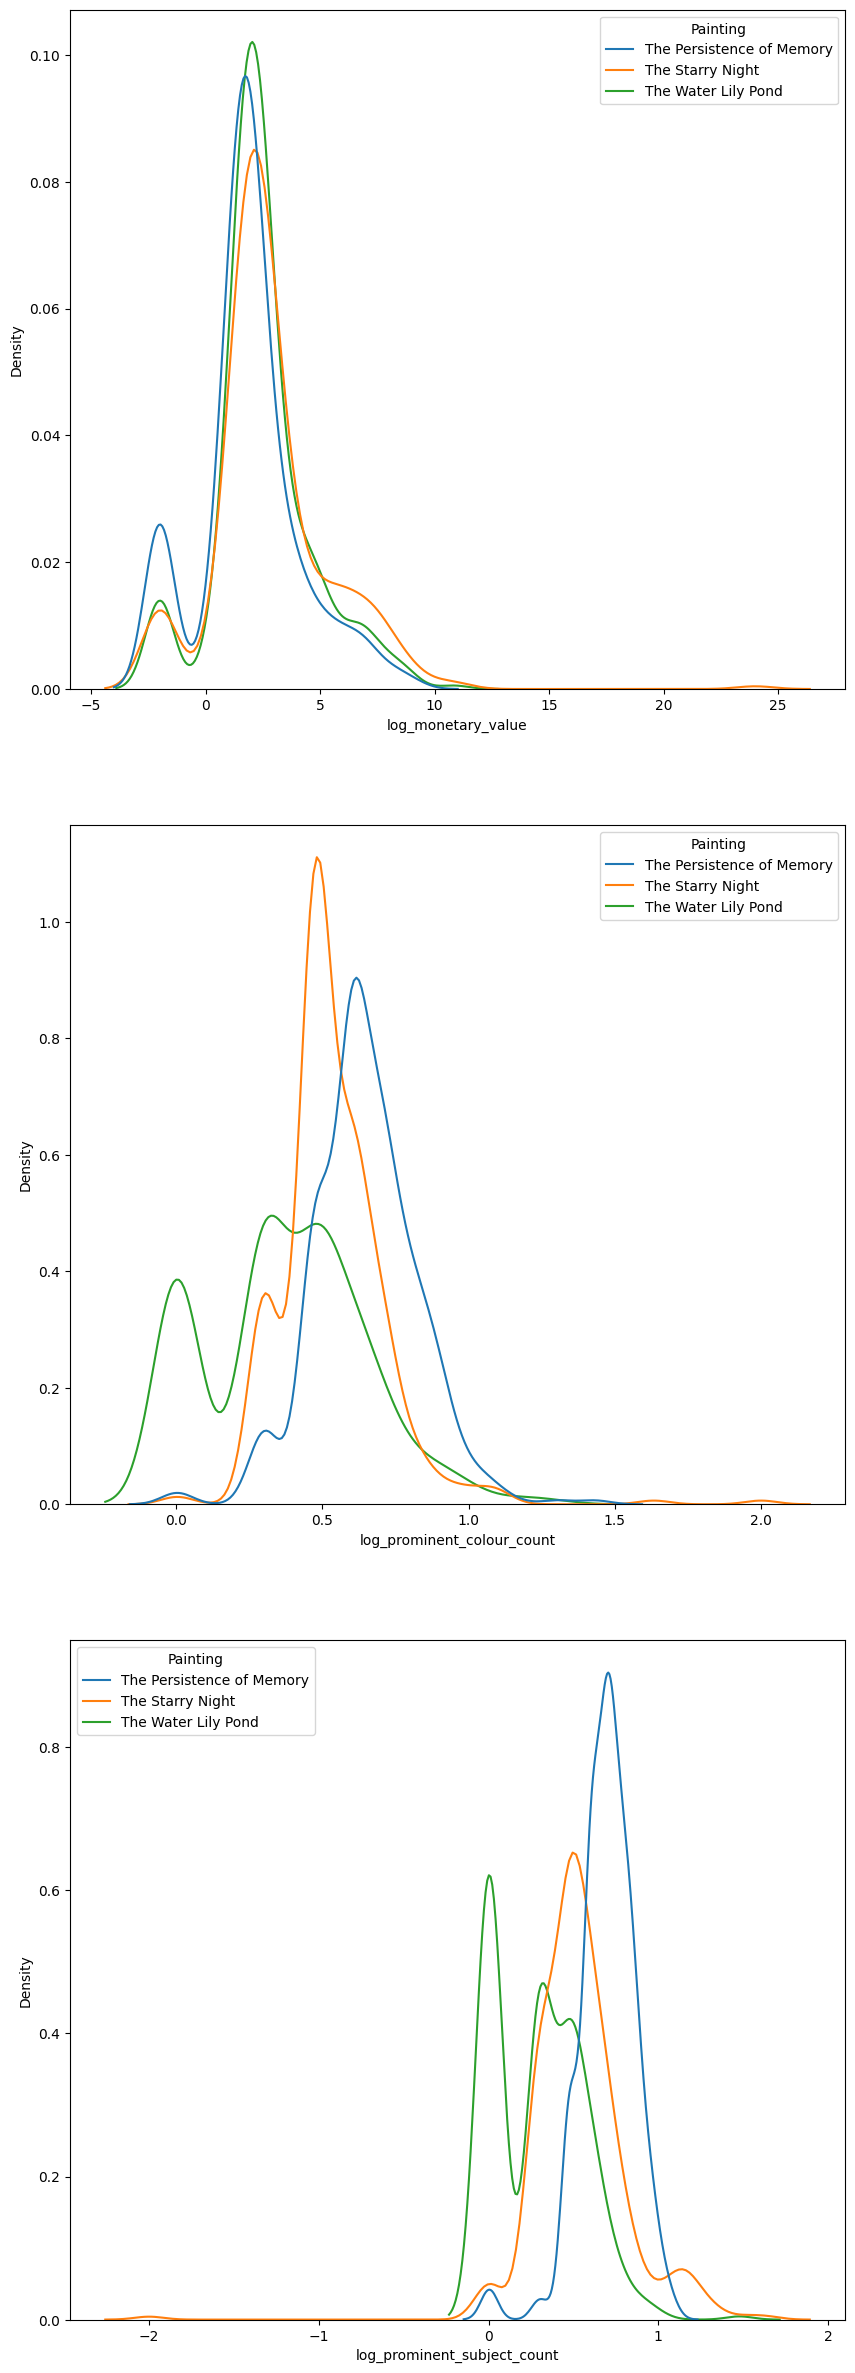

In [29]:
data["log_monetary_value"] = np.log(data["clean_monetary_value"] + 0.01)/np.log(10)
data["log_prominent_colour_count"] = np.log(data["prominent_colour_count"] + 0.01)/np.log(10)
data["log_prominent_subject_count"] = np.log(data["prominent_subject_count"] + 0.01)/np.log(10)


log_vars = ["log_monetary_value", "log_prominent_colour_count", "log_prominent_subject_count"]
fig, ax = plt.subplots(len(log_vars), 1, figsize=(10, 10*len(log_vars)))

for i in range(len(log_vars)):
  sns.kdeplot(data, x=log_vars[i], hue="Painting", ax=ax[i])
plt.savefig("LnNumericKDES.png")


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-2956135014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["sqrt_monetary_value"] = np.sqrt(data["clean_monetary_value"])
/tmp/ipython-input-2956135014.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["sqrt_prominent_colour_count"] = np.sqrt(data["prominent_colour_count"])
/tmp/ipython-input-2956135014

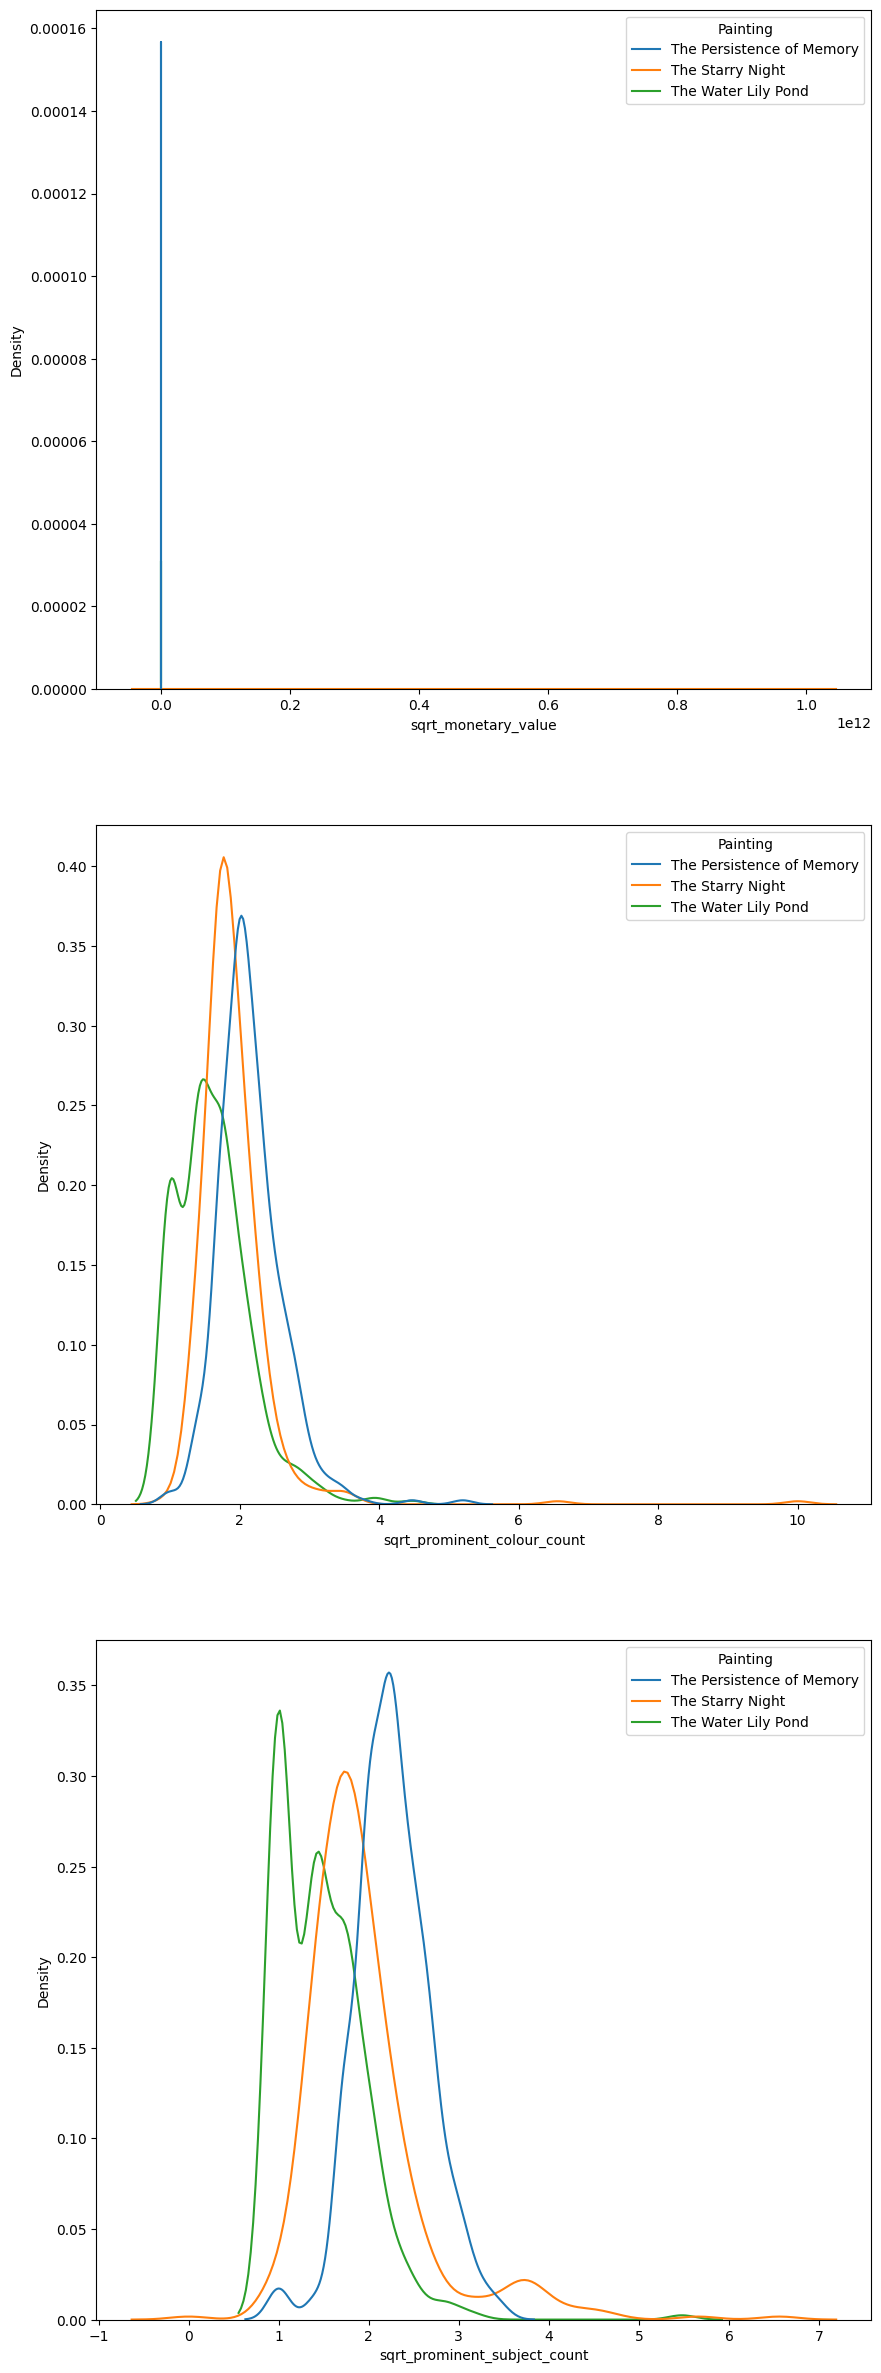

In [28]:
data["sqrt_monetary_value"] = np.sqrt(data["clean_monetary_value"])
data["sqrt_prominent_colour_count"] = np.sqrt(data["prominent_colour_count"])
data["sqrt_prominent_subject_count"] = np.sqrt(data["prominent_subject_count"])

sqrt_vars = ["sqrt_monetary_value", "sqrt_prominent_colour_count", "sqrt_prominent_subject_count"]
fig, ax = plt.subplots(len(sqrt_vars), 1, figsize=(10, 10*len(sqrt_vars)))

for i in range(len(sqrt_vars)):
  sns.kdeplot(data, x=sqrt_vars[i], hue="Painting", ax=ax[i])
  plt.savefig("sqrtNumericKDES.png")